<a href="https://colab.research.google.com/github/crossbone72/AI-Class/blob/main/weak6/DL_abalone_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'
df=pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [ ]:
# Rings를 3개의 그룹으로 분류 (0: 어림, 1: 중간, 2: 많음)
def categorize_rings(x):
    if x <= 8: return 0
    elif x <= 11: return 1
    else: return 2

df['Rings'] = df['Rings'].apply(categorize_rings)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
X=df.drop('Rings',axis=1)
X

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500
1,1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700
2,2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100
3,3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550
4,4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550
...,...,...,...,...,...,...,...,...,...
4172,4172,0,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490
4173,4173,2,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605
4174,4174,2,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080
4175,4175,0,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960


In [ ]:
y=df['Rings']
y

,Rings
0,2
1,0
2,1
3,1
4,0
...,...
4172,1
4173,1
4174,1
4175,1


In [ ]:
import tensorflow as tf
from keras import layers, models
from sklearn.preprocessing import StandardScaler

#데이터 표준화 - 모든 피처의 평균을 0, 분산을 1로 조정하여 학습 효율성 향상
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Y 원-핫 인코딩 실행
Y = pd.get_dummies(y).values

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

#이진 분류를 위한 심층 신경망(DNN) 구조 설계 및 컴파일 설정
model = Sequential()

model.add(Dense(10,input_shape=(9,),activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(3,activation='softmax'))

model.compile(Adam(learning_rate=0.04),'binary_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263 (1.03 KB)

 Trainable params: 263 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#전체 데이터를 학습용과 테스트용(8:2)으로 분리
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
import tensorflow as tf
from keras import layers, models
import numpy as np

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 모델 학습 실행 및 테스트 데이터를 이용한 예측 결과 분석(클래스 변환)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5906 - loss: 0.8801 - val_accuracy: 0.6428 - val_loss: 0.7907
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6295 - loss: 0.8020 - val_accuracy: 0.6577 - val_loss: 0.7628
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6527 - loss: 0.7735 - val_accuracy: 0.6786 - val_loss: 0.7350
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6665 - loss: 0.7524 - val_accuracy: 0.6846 - val_loss: 0.7152
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6654 - loss: 0.7380 - val_accuracy: 0.7010 - val_loss: 0.6970
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6737 - loss: 0.7286 - val_accuracy: 0.6996 - val_loss: 0.6967
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6793 - loss: 0.7241 - val_accuracy: 0.6966 - val_loss: 0.6749
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6800 - loss: 0.7150 - val_accuracy: 0

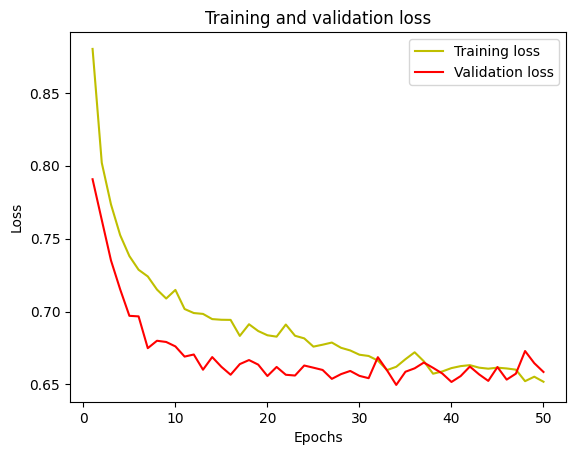

In [ ]:
#학습 손실(Loss)과 검증 손실(Validation Loss) 추이를 시각화하여 모델의 학습 상태 확인
import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

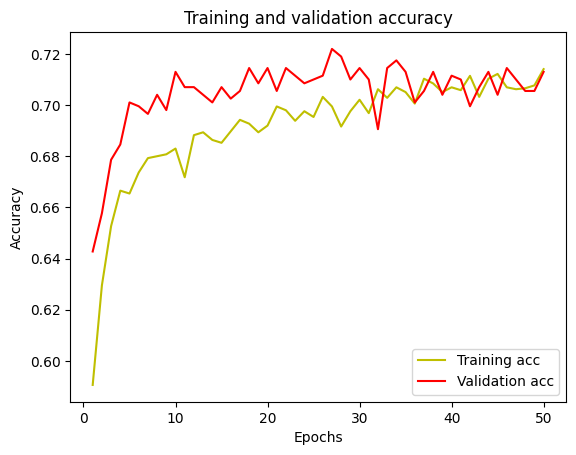

In [ ]:
#학습 정확도(Accuracy)와 검증 정확도(Validation Accuracy) 추이를 시각화하여 분류 성능 확인
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# 최종 모델 성능 평가: 정밀도, 재현율, F1-score 및 혼동 행렬(Confusion Matrix) 출력
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       307
           1       0.63      0.77      0.69       329
           2       0.76      0.54      0.63       200

    accuracy                           0.73       836
   macro avg       0.75      0.71      0.72       836
weighted avg       0.74      0.73      0.73       836

[[247  59   1]
 [ 42 254  33]
 [  3  89 108]]
